In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.5"

import matplotlib.pyplot as plt
import numpy as np

import jax
import jax.numpy as jnp
import optax

from temgym_core.components import Detector
from temgym_core.constants import energy2wavelength
from temgym_core.evaluate import evaluate_gaussians_jax_scan
from temgym_core.gaussian import Lens, circular_input_wave, run_to_end
import sympy as sp

# Import the transfer_matrices module
import sys
sys.path.insert(0, '/home/dl277493/Documents/Code/TemGymCore/tests')
from transfer_matrices import full_abcd_2lens, lens_matrix, propagation_matrix, calculate_z1_and_z2_from_M_and_f, imaging_matrix



jax.config.update("jax_enable_x64", True)

%matplotlib widget


In [2]:
@jax.jit(static_argnames=["num_x", "num_y"])
def simpson2d(f, ax, bx, ay, by, num_x, num_y):
    """
    2D composite Simpson's rule with a trapezoid fallback on the last interval
    when the number of points is even (i.e., odd number of sub-intervals).
    """
    def _weights(num, a, b, dtype):
        h = (b - a) / (num - 1)
        w = jnp.zeros((num,), dtype=dtype)

        use_trap = (num % 2 == 0)
        n_simpson = num - 1 if use_trap else num

        if n_simpson >= 3:
            idx = jax.lax.iota(jnp.int32, n_simpson)
            coeff = 4 - 2 * (idx % 2)
            coeff = coeff.at[0].set(1)
            coeff = coeff.at[-1].set(1)
            w = w.at[:n_simpson].set(coeff * (h / 3))

        if use_trap:
            # Add trapezoid weights for the final interval.
            w = w.at[n_simpson - 1].add(h / 2)
            w = w.at[n_simpson].add(h / 2)

        return w

    dtype = f.dtype
    wx = _weights(num_x, ax, bx, dtype)
    wy = _weights(num_y, ay, by, dtype)

    weights = jnp.outer(wx, wy).ravel()
    return jnp.sum(f * weights)

@jax.jit
def vector_matmul(a, M, b):
    out = (a @ M) * b
    return jnp.sum(out, axis=-1)

@jax.jit
def eval_collins(A, B, D, r1, r2, E1, k):

    B_inv = np.linalg.inv(B)
    DB_inv = D @ B_inv 
    B_invA = B_inv @ A

    first_term = vector_matmul(r2, DB_inv, r2)
    second_term = vector_matmul(r1, B_invA, r1)
    third_term = -2 * vector_matmul(r1, B_inv, r2)

    return E1 * np.exp(-1j * k / 2 * (first_term + second_term + third_term))


In [3]:

# Continue symbolic analysis with polynomial degree analysis
print("\n" + "="*70)
print("POLYNOMIAL DEGREE ANALYSIS")
print("="*70)

z1_sym, z2_sym, z3_sym, f1_sym, f2_sym, A = sp.symbols("z1 z2 z3 f1 f2 A")



POLYNOMIAL DEGREE ANALYSIS


## Imaging Regime Constraints (Measured $M$ and Defocus)

In imaging mode, we can use **measured magnification** $M$ and **known defocus** $\Delta z$ to add strong constraints:

- **$A = M$** (magnification constraint)
- **$B = M\,\Delta z$** (defocus constraint)

This gives **two constraints per defocus plane**, which greatly improves identifiability and stability.

### Counting Constraints

**Unknowns:** 4 effective parameters (after imposing relationships across images)
- $f_1, f_2, z_1, z_2$ (with $z_3$ fixed or known)

**Constraints from defocused images:**
- Each image provides intensity matching
- Each image also provides **$A$ and $B$ constraints** via measured $M$ and known $\Delta z$

**Practical takeaway:**
- 3–4 images are typically sufficient
- 5+ images give robust fits under noise

### Should You Wobble a Lens?

**Strategy 1: Vary defocus at fixed lens positions** (Current approach)
- Move sample by known $\Delta z$
- Use measured magnification $M$
- Cost: $N$ forward evaluations

**Strategy 2: Wobble lens 2 by unknown amount** (Enhanced)
- Adds extra diversity if $f_1$ and $f_2$ are ambiguous
- More complex (additional unknowns)

**Recommendation:** start with Strategy 1 + $A/B$ constraints, then wobble only if needed.


## Part 2: Practical Implementation

Setup and imports (continue from beginning)


In [39]:

# Geometry and forward model
voltage = 100_000  # V
wavelength = energy2wavelength(voltage)

# Geometry
input_window_width = 75e-6
aperture_radius = 10e-6

# True parameters for synthetic data
# These values satisfy the imaging condition A = 0
# With realistic distances between components

f1_true = 2.5e-5
f2_true = 5e-4
M1 = -100
M2 = -500

z1_lens_1, z2_lens_1 = calculate_z1_and_z2_from_M_and_f(M1, f1_true)
z1_lens_2, z2_lens_2 = calculate_z1_and_z2_from_M_and_f(M2, f2_true)

z1_true = abs(z1_lens_1)
z2_true = abs(z2_lens_1) + abs(z1_lens_2)
z3_true = abs(z2_lens_2)

print(f"Total distances: z1 = {z1_true:.2e} m, z2 = {z2_true:.2e} m, z3 = {z3_true:.2e} m")

z1_def = sp.symbols('z1_def')
# Compute symbolic ABCD matrix with symbolic=True
z1_sym_abcd, z2_sym_abcd, z3_sym_abcd, f1_sym_abcd, f2_sym_abcd = sp.symbols('z1 z2 z3 f1 f2')
M_symbolic = full_abcd_2lens((z1_sym_abcd + z1_def, z2_sym_abcd, z3_sym_abcd), f1_sym_abcd, f2_sym_abcd, symbolic=True)
display(M_symbolic)
M_true = full_abcd_2lens((z1_true, z2_true, z3_true), f1_true, f2_true, symbolic=False)
print(M_true)

imaging_matrix_1 = imaging_matrix(M1, f1_true) @ propagation_matrix(z1_def)
imaging_matrix_2 = imaging_matrix(M2, f2_true)

total = imaging_matrix_2 @ imaging_matrix_1

display(total)



Total distances: z1 = 2.53e-05 m, z2 = 3.03e-03 m, z3 = 2.51e-01 m


Matrix([
[1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1, z2*(1 - z3/f2) + z3 + (z1 + z1_def)*(1 - z3/f2 - (z2*(1 - z3/f2) + z3)/f1), 0],
[              -1/f2 - (1 - z2/f2)/f1,                         (-1/f2 - (1 - z2/f2)/f1)*(z1 + z1_def) + 1 - z2/f2, 0],
[                                   0,                                                                          0, 1]])

[[5.0000e+04 0.0000e+00 0.0000e+00]
 [2.0008e+05 2.0000e-05 0.0000e+00]
 [0.0000e+00 0.0000e+00 1.0000e+00]]


Matrix([
[   50000,             50000*z1_def, 0],
[200080.0, 200080.0*z1_def + 2.0e-5, 0],
[       0,                        0, 1]])

Number of input rays: 13963

True parameters:
  f1 = 0.025000 mm
  f2 = 0.500000 mm
  z1 = 0.025250 mm
  z2 = 3.026000 mm
  z3 = 250.500000 mm


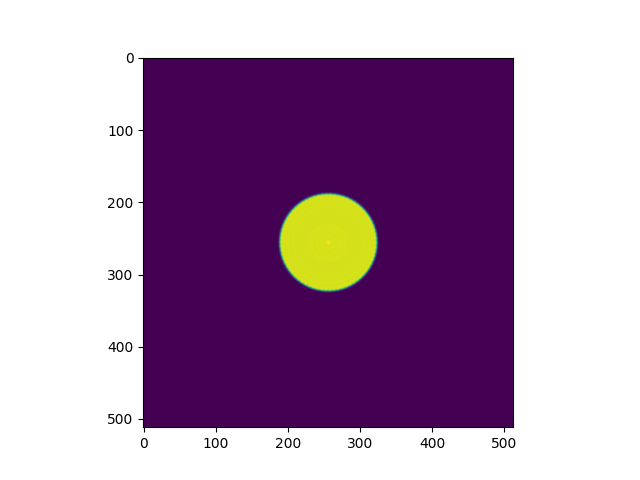

In [40]:
run_to_end_vmapped = jax.vmap(run_to_end, in_axes=(0, None))

Nx = Ny = 512
input_pixel = input_window_width / Nx


# Grids
input_grid = Detector(
    z=0.0,
    pixel_size=(input_pixel, input_pixel),
    shape=(Ny, Nx),
)
# Output grid at detector (z3 distance from last lens)
output_grid = Detector(
    z=z1_true + z2_true + z3_true,
    pixel_size=(input_pixel * abs(M1 * M2), input_pixel * abs(M1 * M2)),
    shape=(Ny, Nx),
)

input_extent = input_grid.extent
output_extent = output_grid.extent
output_x, output_y = output_grid.coords_1d

# Aperture and vmap function
input_waist = 3e-7
rays_in = circular_input_wave(
    voltage=voltage,
    aperture_radius=aperture_radius,
    waist=input_waist,
    offset_xy=(0.0, 0.0),
    sampling="uniform",
).to_vector()

rays_after_aperture = run_to_end(rays_in, ())
input_aperture_field = evaluate_gaussians_jax_scan(
    rays_after_aperture, input_grid, batch_size=128
)

plt.figure()
plt.imshow(np.abs(input_aperture_field) ** 2)


print(f'Number of input rays: {rays_in.x.shape[0]}')
print(f'\nTrue parameters:')
print(f'  f1 = {f1_true*1e3:.6f} mm')
print(f'  f2 = {f2_true*1e3:.6f} mm')
print(f'  z1 = {z1_true*1e3:.6f} mm')
print(f'  z2 = {z2_true*1e3:.6f} mm')
print(f'  z3 = {z3_true*1e3:.6f} mm')

In [43]:
# Simpson-based Collins propagation with scalar A, B, D (pixel-size scaled)
input_x, input_y = input_grid.coords_1d
X1, Y1 = jnp.meshgrid(input_x, input_y, indexing="xy")
U1 = jnp.asarray(input_aperture_field)

L0 = input_pixel
x1_t = X1 / L0
y1_t = Y1 / L0

k_t = 2 * jnp.pi / (1000e-9 / L0)
print(k_t)
A_t = 1.0
B_t = z1_true / L0
D_t = 1.0

@jax.jit(static_argnames=["num_x", "num_y"])
def eval_collins_scalar_simpson_scaled(U1, x1_t, y1_t, x2_t, y2_t, A_t, B_t, D_t, k_t, ax_t, bx_t, ay_t, by_t, num_x, num_y):
    phase = (A_t * (x1_t**2 + y1_t**2) - 2 * (x1_t * x2_t + y1_t * y2_t) + D_t * (x2_t**2 + y2_t**2))
    kernel = jnp.exp(-1j * k_t / (2 * B_t) * phase)
    integrand = (U1 * kernel).T  # transpose to align with x-first weights
    return simpson2d(integrand.ravel(), ax_t, bx_t, ay_t, by_t, num_x, num_y) / (1j * (wavelength / L0) * B_t)

ax_t, bx_t = (input_x[0] / L0), (input_x[-1] / L0)
ay_t, by_t = (input_y[0] / L0), (input_y[-1] / L0)
num_x = input_x.shape[0]
num_y = input_y.shape[0]

# Small output grid for a quick sanity check
out_n = 512
x2 = jnp.linspace(input_x[0], input_x[-1], out_n)
y2 = jnp.linspace(input_y[0], input_y[-1], out_n)
X2, Y2 = jnp.meshgrid(x2, y2, indexing="xy")
x2_t = X2 / L0
y2_t = Y2 / L0


0.9203884727313847


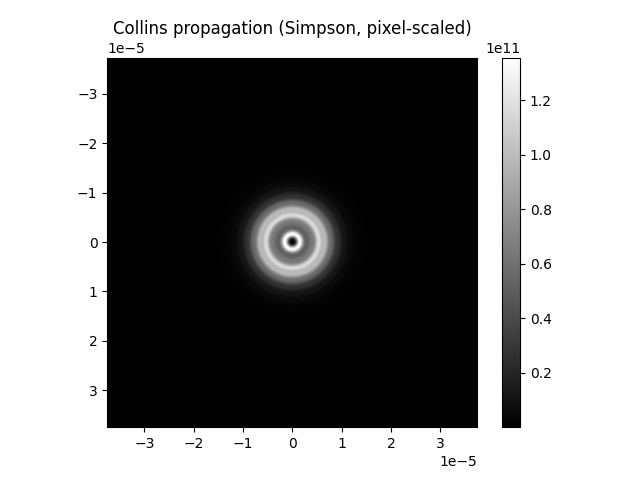

In [44]:

points = jnp.stack([x2_t.ravel(), y2_t.ravel()], axis=-1)
U2_flat = jax.vmap(
    lambda p: eval_collins_scalar_simpson_scaled(U1, x1_t, y1_t, p[0], p[1], A_t, B_t, D_t, k_t, ax_t, bx_t, ay_t, by_t, num_x, num_y)
)(points)
U2 = U2_flat.reshape(X2.shape)

plt.figure()
plt.imshow(np.abs(U2) ** 2, extent=(input_x[0], input_x[-1], input_y[0], input_y[-1]), origin="lower", cmap="gray")
plt.title("Collins propagation (Simpson, pixel-scaled)")
plt.colorbar()

## Optimization Parameters


In [19]:

# === CHOOSE PARAMETERS HERE ===

# Loss function choice
loss_type_to_use = 'l2'  # Options: 'l2', 'ncc', 'hybrid', 'ssim', 'log'

# Optimizer choice
optimizer_type = 'adam'  # Options: 'lbfgs', 'adam'

# Adam learning rate (if using Adam)
adam_learning_rate = 1e-7

# Number of optimization steps
n_steps = 300 if optimizer_type == 'adam' else 50

# Defocus sampling
n_defocus = 5
z_defocus_step = -1e-1  # meters per defocus step

# Measured magnification in imaging mode (known from experiment)
M_measured = M1 * M2  # example value; set from measurement

# Constraint weights
lambda_A = 1e-1  # A = M constraint
lambda_B = 1e-1  # B = M * defocus constraint
lambda_mag = 0.0 # Regularization toward prior (set to 0 for now)

print(f"Configuration:")
print(f"  Loss function: {loss_type_to_use}")
print(f"  Optimizer: {optimizer_type}")
print(f"  Number of steps: {n_steps}")
print(f"  Number of defocus images: {n_defocus}")
print(f"  Defocus step: {z_defocus_step:.2e} m")
print(f"  Measured magnification: M = {M_measured}")
print(f"  Lambda weights: A={lambda_A}, B={lambda_B}, mag={lambda_mag}")
print(f"\nNote: Without heatmap visualization, we'll rely on loss history")
print(f"and random initialization + multiple restarts for robustness.")


Configuration:
  Loss function: l2
  Optimizer: adam
  Number of steps: 300
  Number of defocus images: 5
  Defocus step: -1.00e-01 m
  Measured magnification: M = 50000
  Lambda weights: A=0.1, B=0.1, mag=0.0

Note: Without heatmap visualization, we'll rely on loss history
and random initialization + multiple restarts for robustness.


## Loss Functions (same as single lens)


In [20]:

eps = 1e-12

def l2_intensity_loss(I_sim, I_target):
    """L2 (MSE) intensity loss"""
    return jnp.mean((I_sim - I_target) ** 2)

def log_intensity_loss(I_sim, I_target):
    """Log-intensity loss"""
    return jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)

def ncc_loss(I_sim, I_target):
    """Normalized cross-correlation"""
    I_sim_norm = (I_sim - jnp.mean(I_sim)) / (jnp.std(I_sim) + eps)
    I_target_norm = (I_target - jnp.mean(I_target)) / (jnp.std(I_target) + eps)
    return -jnp.mean(I_sim_norm * I_target_norm)

def hybrid_loss(I_sim, I_target, alpha=0.5):
    """Hybrid L2 + log loss"""
    l2 = jnp.mean((I_sim - I_target) ** 2)
    log_loss = jnp.mean((jnp.log(I_sim + eps) - jnp.log(I_target + eps)) ** 2)
    return alpha * l2 + (1 - alpha) * log_loss

def ssim_loss(I_sim, I_target, C1=1e-4, C2=1e-3):
    """Structural similarity inspired loss"""
    mu_sim = jnp.mean(I_sim)
    mu_target = jnp.mean(I_target)
    sigma_sim = jnp.std(I_sim)
    sigma_target = jnp.std(I_target)
    sigma_sim_target = jnp.mean((I_sim - mu_sim) * (I_target - mu_target))
    
    luminance = (2 * mu_sim * mu_target + C1) / (mu_sim**2 + mu_target**2 + C1)
    contrast = (2 * sigma_sim * sigma_target + C2) / (sigma_sim**2 + sigma_target**2 + C2)
    structure = (sigma_sim_target + C2/2) / (sigma_sim * sigma_target + C2/2)
    
    return 1 - luminance * contrast * structure


## Imaging Constraints for Two-Lens System

In imaging mode we use **measured magnification** $M$ and **known defocus** $\Delta z$:

- $A = M$
- $B = M\,\Delta z$

These constraints are enforced **per defocus plane** in the loss, alongside the intensity match.


In [21]:
def propagation_matrix(z):
    return jnp.array([[1.0, z, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0]],
                         dtype=jnp.float64)
def lens_matrix(f):
    return jnp.array([[1.0, 0.0, 0.0], [-1/f, 1.0, 0.0], [0.0, 0.0, 1.0]],
                         dtype=jnp.float64)

def abcd_2lens(z1, z2, z3, f1, f2):
    """Compute ABCD matrix for two-lens system."""
    M1 = lens_matrix(f1)
    M2 = lens_matrix(f2)
    P1 = propagation_matrix(z1)
    P2 = propagation_matrix(z2)
    P3 = propagation_matrix(z3)
    
    # Total ABCD matrix: P3 @ M2 @ P2 @ M1 @ P1
    M_total = P3 @ M2 @ P2 @ M1 @ P1
    A, B, _, _ = M_total[0, 0], M_total[0, 1], M_total[1, 0], M_total[1, 1]
    return A, B


def imaging_constraint_penalty_two_lens(f1, f2, z1, z2, z3, z_def, M_measured, lambda_A=10.0, lambda_B=10.0):
    """Penalty for imaging constraints in the measured regime: A = M, B = M * defocus."""
    A, B = abcd_2lens(z1 + z_def, z2, z3, f1, f2)
    penalty_A = lambda_A * (A - M_measured) ** 2
    penalty_B = lambda_B * (B - M_measured * z_def) ** 2
    return penalty_A + penalty_B

print("Two-lens imaging constraints:")
print("A = M (measured magnification)")
print("B = M * defocus")
print("\nThese are enforced per defocus plane in the loss.")


Two-lens imaging constraints:
A = M (measured magnification)
B = M * defocus

These are enforced per defocus plane in the loss.


## Generate Synthetic Measurements


Generating synthetic measurements...
2.525e-05
  Image 1/5
-0.09997475
  Image 2/5
-0.19997475
  Image 3/5
-0.29997475000000007
  Image 4/5
-0.39997475000000005
  Image 5/5
Generated 5 synthetic measurements


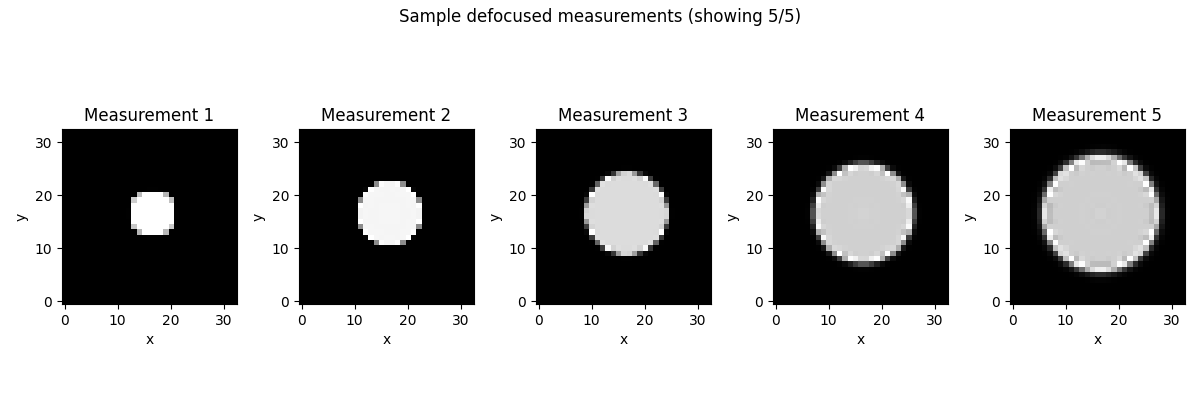

In [22]:

# Forward model for two-lens system
def forward_intensity_two_lens(f1, f2, z1, z2, z3):
    """Forward model: compute intensity through two-lens system"""
    # Create lens objects
    lens1 = Lens(z=z1, focal_length=f1)
    lens2 = Lens(z=z1 + z2, focal_length=f2)

    rays_at_end = run_to_end_vmapped(rays_in, (lens1, lens2, output_grid))
    
    # Evaluate at detector (z3 from lens 2)
    field = evaluate_gaussians_jax_scan(rays_at_end, output_grid, batch_size=32)
    intensity = jnp.abs(field) ** 2
    return intensity / jnp.sum(intensity)

# Generate synthetic measurements with defocus
z_defocus_amounts = jnp.linspace(0.0, (n_defocus - 1) * z_defocus_step, n_defocus)

print("Generating synthetic measurements...")
I_meas_two_lens = []
for i, z_def in enumerate(z_defocus_amounts):
    # Vary z1 position for defocus
    z1_def = z1_true + z_def
    print(z1_def)
    I = forward_intensity_two_lens(f1_true, f2_true, z1_def, z2_true, z3_true)
    I_meas_two_lens.append(I)
    print(f"  Image {i+1}/{n_defocus}")

I_meas_two_lens = jnp.array(I_meas_two_lens)
print(f"Generated {len(I_meas_two_lens)} synthetic measurements")

# Visualize measurements
fig, axs = plt.subplots(1, min(5, n_defocus), figsize=(12, 4))
for i in range(min(5, n_defocus)):
    axs[i].imshow(np.asarray(I_meas_two_lens[i]), cmap='gray', origin='lower')
    axs[i].set_title(f'Measurement {i+1}')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('y')
plt.suptitle(f"Sample defocused measurements (showing {min(5, n_defocus)}/{n_defocus})")
plt.tight_layout()


## Loss Function and Optimization


Initial parameters:
  f1_init = 0.023750 mm (true: 0.025000 mm)
  f2_init = 0.475000 mm (true: 0.500000 mm)
  z1_init = 0.026513 mm (true: 0.025250 mm)
  z2_init = 2.874700 mm (true: 3.026000 mm)
  z3_init = 263.025000 mm (true: 250.500000 mm)


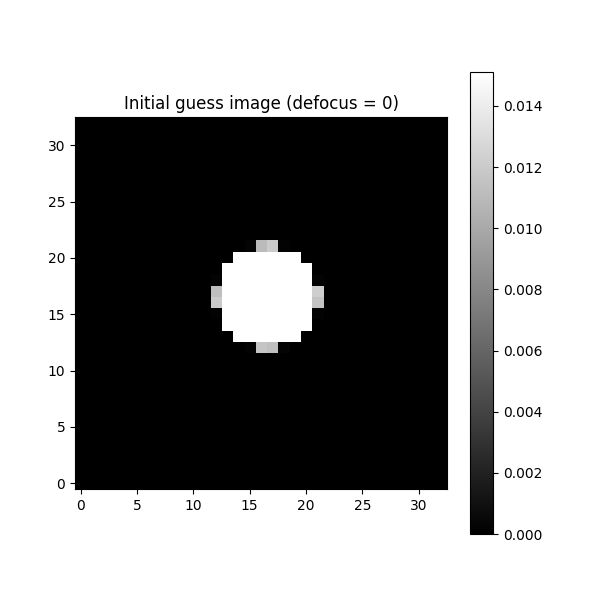

Loss (initial params): 1.475186e+07


In [23]:

def unpack_params_two_lens(params):
    """Unpack parameters: f1, f2, z1, z2, z3"""
    f1 = jnp.abs(params[0]) + eps
    f2 = jnp.abs(params[1]) + eps
    z1 = jnp.abs(params[2]) + eps
    z2 = jnp.abs(params[3]) + eps
    z3 = jnp.abs(params[4]) + eps
    return f1, f2, z1, z2, z3

def loss_fn_two_lens(params, loss_type='l2', z_defocus_amounts=z_defocus_amounts):
    """Loss function for two-lens system with A/B constraints in imaging regime"""

    f1, f2, z1, z2, z3 = unpack_params_two_lens(params)
    
    def one_image(z_def, I_target):
        """Loss for a single defocused image"""
        z1_def = z1 + z_def
        I_sim = forward_intensity_two_lens(f1, f2, z1_def, z2, z3)
        
        if loss_type == 'l2':
            data = l2_intensity_loss(I_sim, I_target)
        elif loss_type == 'ncc':
            data = ncc_loss(I_sim, I_target)
        elif loss_type == 'hybrid':
            data = hybrid_loss(I_sim, I_target, alpha=0.5)
        elif loss_type == 'ssim':
            data = ssim_loss(I_sim, I_target)
        else:  # 'log'
            data = log_intensity_loss(I_sim, I_target)
        
        # Add A/B constraints for imaging regime
        constraint = imaging_constraint_penalty_two_lens(
            f1, f2, z1, z2, z3, z_def, M_measured, lambda_A=lambda_A, lambda_B=lambda_B
        )
        
        return data + constraint
    
    data_loss = jnp.sum(jax.vmap(one_image)(z_defocus_amounts, I_meas_two_lens))
    
    return data_loss

# Create JIT compiled loss function
loss_fn_two_lens_jit = jax.jit(lambda p: loss_fn_two_lens(p, loss_type=loss_type_to_use, z_defocus_amounts=z_defocus_amounts))

# Initialize parameters (start with good guesses but some perturbation)
params_init_two_lens = jnp.array([
    f1_true * 0.95,  # f1 (start 10% off)
    f2_true * 0.95,  # f2 (start 10% off)
    z1_true * 1.05, # z1
    z2_true * 0.95, # z2
    z3_true * 1.05,  # z3
    ])

print(f"Initial parameters:")
print(f"  f1_init = {params_init_two_lens[0]*1e3:.6f} mm (true: {f1_true*1e3:.6f} mm)")
print(f"  f2_init = {params_init_two_lens[1]*1e3:.6f} mm (true: {f2_true*1e3:.6f} mm)")
print(f"  z1_init = {params_init_two_lens[2]*1e3:.6f} mm (true: {z1_true*1e3:.6f} mm)")
print(f"  z2_init = {params_init_two_lens[3]*1e3:.6f} mm (true: {z2_true*1e3:.6f} mm)")
print(f"  z3_init = {params_init_two_lens[4]*1e3:.6f} mm (true: {z3_true*1e3:.6f} mm)")


# Plot initial simulated image from the initial parameter guess (first defocus = 0)
f1_init, f2_init, z1_init, z2_init, z3_init = unpack_params_two_lens(params_init_two_lens)
z_def0 = z_defocus_amounts[0]
I_init = forward_intensity_two_lens(f1_init, f2_init, z1_init + z_def0, z2_init, z3_init)

plt.figure(figsize=(6,6))
plt.imshow(np.asarray(I_init), cmap='gray', origin='lower')
plt.title('Initial guess image (defocus = 0)')
plt.colorbar()
plt.show()

loss_init = loss_fn_two_lens(params_init_two_lens)
print(f"Loss (initial params): {float(loss_init):.6e}")


In [24]:
# Memory-efficient gradient computation using jax.jvp (forward-mode autodiff)
def compute_value_and_grad_jvp(f, params):
    """Compute value and gradient using jax.jvp (memory-efficient forward-mode autodiff)"""
    value = f(params)
    n_params = params.shape[0]
    grads = []
    
    for i in range(n_params):
        # Create one-hot tangent vector for i-th parameter
        tangent = jnp.zeros_like(params)
        tangent = tangent.at[i].set(1.0)
        
        # Compute JVP: (primals, tangents) -> grad_i
        _, grad_i = jax.jvp(f, (params,), (tangent,))
        grads.append(grad_i)
    
    return value, jnp.array(grads)

# Setup optimizer
if optimizer_type == 'lbfgs':
    optimizer = optax.lbfgs(memory_size=20)
    opt_state = optimizer.init(params_init_two_lens)
    use_lbfgs = True
elif optimizer_type == 'adam':
    # Use learning rate schedule for Adam (decay over time)
    schedule = optax.exponential_decay(init_value=adam_learning_rate, transition_steps=100, decay_rate=0.96)
    optimizer = optax.adam(learning_rate=schedule)
    opt_state = optimizer.init(params_init_two_lens)
    use_lbfgs = False
else:
    raise ValueError(f"Unknown optimizer: {optimizer_type}")

loss_history = []
f1_history = []
f2_history = []
z1_history = []
z2_history = []
z3_history = []

params = params_init_two_lens
opt_state_local = opt_state

print(f"\n{'='*70}")
print(f"Starting {optimizer_type.upper()} optimization with {loss_type_to_use} loss")
print(f"{'='*70}\n")

for i in range(n_steps):
    # Compute value and gradient using memory-efficient JVP
    loss, grads = compute_value_and_grad_jvp(loss_fn_two_lens_jit, params)
    
    if use_lbfgs:
        updates, opt_state_local = optimizer.update(
            grads,
            opt_state_local,
            params=params,
            value=loss,
            grad=grads,
            value_fn=loss_fn_two_lens_jit,
        )
    else:
        updates, opt_state_local = optimizer.update(grads, opt_state_local, params)
    
    params = optax.apply_updates(params, updates)
    f1, f2, z1, z2, z3 = unpack_params_two_lens(params)
    
    loss_history.append(float(loss))
    f1_history.append(float(f1))
    f2_history.append(float(f2))
    z1_history.append(float(z1))
    z2_history.append(float(z2))
    z3_history.append(float(z3))
    
    print(f"Step {i:3d}, Loss: {loss:.6e}")
    print(f"  f1: {float(f1)*1e3:.6f} mm, f2: {float(f2)*1e3:.6f} mm, z1: {float(z1)*1e3:.6f} mm, z2: {float(z2)*1e3:.6f} mm, z3: {float(z3)*1e3:.6f} mm")

print(f"\n{'='*70}")
print(f"Final fitted values:")
print(f"  f1_fit     = {f1_history[-1]*1e3:.6f} mm (true: {f1_true*1e3:.6f} mm, error: {abs(f1_history[-1] - f1_true)/f1_true * 100:.2f}%)")
print(f"  f2_fit     = {f2_history[-1]*1e3:.6f} mm (true: {f2_true*1e3:.6f} mm, error: {abs(f2_history[-1] - f2_true)/f2_true * 100:.2f}%)")
print(f"  z1_fit     = {z1_history[-1]*1e3:.6f} mm (true: {z1_true*1e3:.6f} mm, error: {abs(z1_history[-1] - z1_true)/z1_true * 100:.2f}%)")
print(f"  z2_fit     = {z2_history[-1]*1e3:.6f} mm (true: {z2_true*1e3:.6f} mm, error: {abs(z2_history[-1] - z2_true)/z2_true * 100:.2f}%)")
print(f"  z3_fit     = {z3_history[-1]*1e3:.6f} mm (true: {z3_true*1e3:.6f} mm, error: {abs(z3_history[-1] - z3_true)/z3_true * 100:.2f}%)")
print(f"{'='*70}")


Starting ADAM optimization with l2 loss

Step   0, Loss: 1.475186e+07
  f1: 0.023850 mm, f2: 0.475100 mm, z1: 0.026613 mm, z2: 2.874600 mm, z3: 263.024900 mm
Step   1, Loss: 1.338503e+07
  f1: 0.023950 mm, f2: 0.475200 mm, z1: 0.026712 mm, z2: 2.874500 mm, z3: 263.024800 mm
Step   2, Loss: 1.209815e+07
  f1: 0.024049 mm, f2: 0.475299 mm, z1: 0.026812 mm, z2: 2.874401 mm, z3: 263.024701 mm
Step   3, Loss: 1.089049e+07
  f1: 0.024148 mm, f2: 0.475398 mm, z1: 0.026911 mm, z2: 2.874302 mm, z3: 263.024602 mm
Step   4, Loss: 9.761111e+06
  f1: 0.024246 mm, f2: 0.475497 mm, z1: 0.027009 mm, z2: 2.874203 mm, z3: 263.024503 mm
Step   5, Loss: 8.708784e+06
  f1: 0.024344 mm, f2: 0.475594 mm, z1: 0.027107 mm, z2: 2.874106 mm, z3: 263.024406 mm
Step   6, Loss: 7.732043e+06
  f1: 0.024440 mm, f2: 0.475691 mm, z1: 0.027203 mm, z2: 2.874009 mm, z3: 263.024309 mm
Step   7, Loss: 6.829166e+06
  f1: 0.024536 mm, f2: 0.475787 mm, z1: 0.027299 mm, z2: 2.873913 mm, z3: 263.024213 mm
Step   8, Loss: 5.9981

## Convergence Analysis


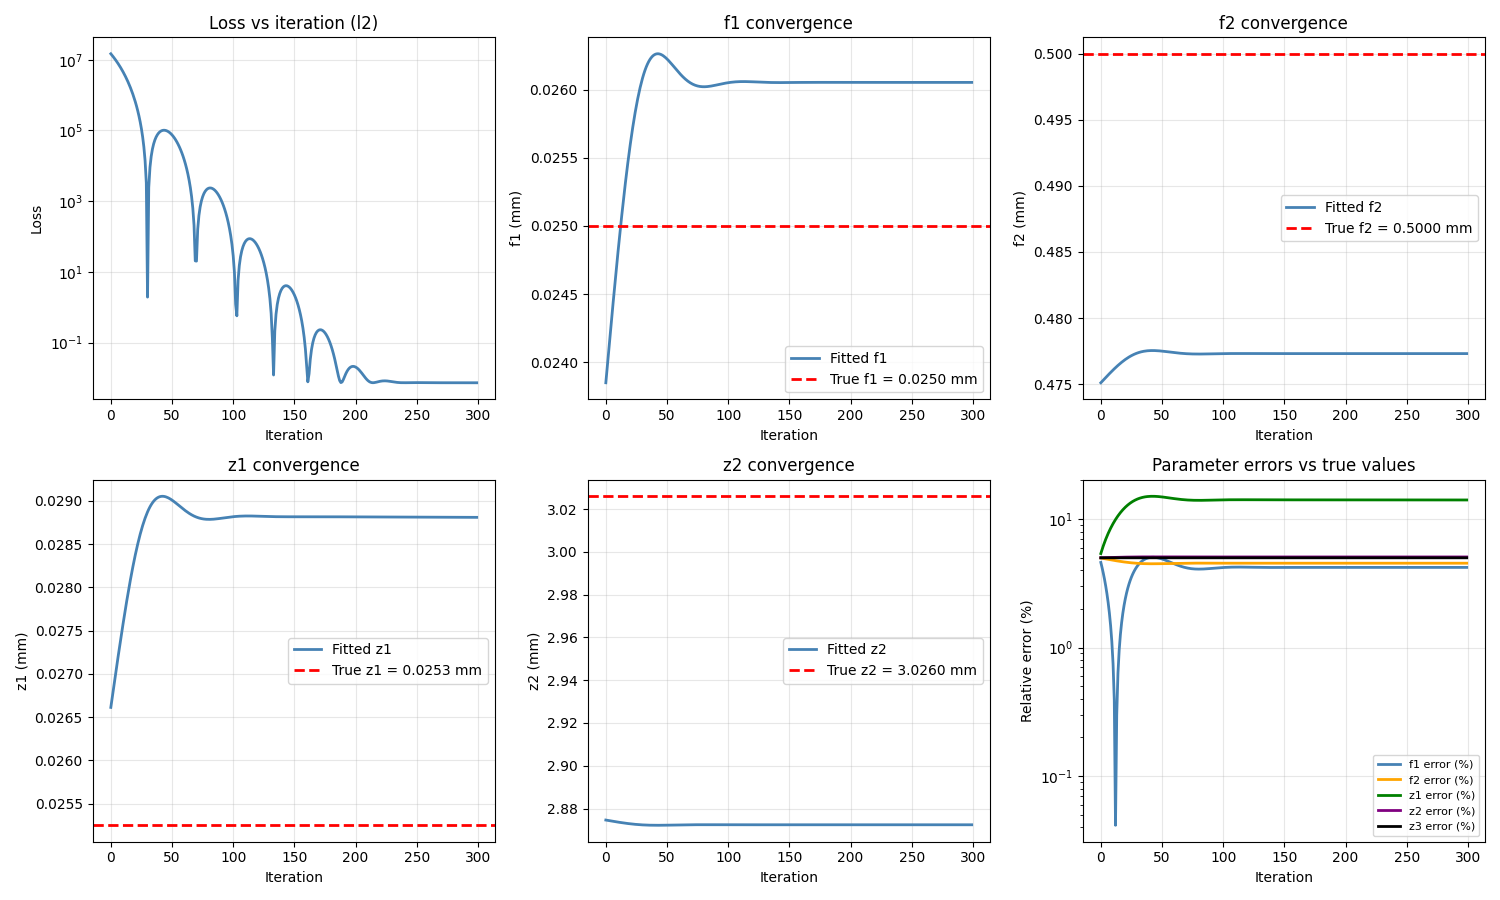


Final relative errors:
  f1: 4.21%
  f2: 4.54%
  z1: 14.10%
  z2: 5.08%
  z3: 5.00%


: 

In [ ]:

# Plot convergence
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Loss history
axes[0, 0].semilogy(loss_history, lw=2, color='steelblue')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title(f'Loss vs iteration ({loss_type_to_use})')
axes[0, 0].grid(True, alpha=0.3)

# f1 convergence
axes[0, 1].plot(np.array(f1_history) * 1e3, lw=2, color='steelblue', label='Fitted f1')
axes[0, 1].axhline(f1_true * 1e3, color='red', linestyle='--', lw=2, label=f'True f1 = {f1_true*1e3:.4f} mm')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('f1 (mm)')
axes[0, 1].set_title('f1 convergence')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# f2 convergence
axes[0, 2].plot(np.array(f2_history) * 1e3, lw=2, color='steelblue', label='Fitted f2')
axes[0, 2].axhline(f2_true * 1e3, color='red', linestyle='--', lw=2, label=f'True f2 = {f2_true*1e3:.4f} mm')
axes[0, 2].set_xlabel('Iteration')
axes[0, 2].set_ylabel('f2 (mm)')
axes[0, 2].set_title('f2 convergence')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# z1 convergence
axes[1, 0].plot(np.array(z1_history) * 1e3, lw=2, color='steelblue', label='Fitted z1')
axes[1, 0].axhline(z1_true * 1e3, color='red', linestyle='--', lw=2, label=f'True z1 = {z1_true*1e3:.4f} mm')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('z1 (mm)')
axes[1, 0].set_title('z1 convergence')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# z2 convergence
axes[1, 1].plot(np.array(z2_history) * 1e3, lw=2, color='steelblue', label='Fitted z2')
axes[1, 1].axhline(z2_true * 1e3, color='red', linestyle='--', lw=2, label=f'True z2 = {z2_true*1e3:.4f} mm')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('z2 (mm)')
axes[1, 1].set_title('z2 convergence')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Relative errors
f1_errors = np.abs(np.array(f1_history) - f1_true) / f1_true * 100
f2_errors = np.abs(np.array(f2_history) - f2_true) / f2_true * 100
z1_errors = np.abs(np.array(z1_history) - z1_true) / z1_true * 100
z2_errors = np.abs(np.array(z2_history) - z2_true) / z2_true * 100
z3_errors = np.abs(np.array(z3_history) - z3_true) / z3_true * 100

axes[1, 2].semilogy(f1_errors, lw=2, label='f1 error (%)', color='steelblue')
axes[1, 2].semilogy(f2_errors, lw=2, label='f2 error (%)', color='orange')
axes[1, 2].semilogy(z1_errors, lw=2, label='z1 error (%)', color='green')
axes[1, 2].semilogy(z2_errors, lw=2, label='z2 error (%)', color='purple')
axes[1, 2].semilogy(z3_errors, lw=2, label='z3 error (%)', color='black')
axes[1, 2].set_xlabel('Iteration')
axes[1, 2].set_ylabel('Relative error (%)')
axes[1, 2].set_title('Parameter errors vs true values')
axes[1, 2].legend(fontsize=8)
axes[1, 2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nFinal relative errors:")
print(f"  f1: {f1_errors[-1]:.2f}%")
print(f"  f2: {f2_errors[-1]:.2f}%")
print(f"  z1: {z1_errors[-1]:.2f}%")
print(f"  z2: {z2_errors[-1]:.2f}%")
print(f"  z3: {z3_errors[-1]:.2f}%")
